# Prithvi WxC Downscaling with ECCC Data: Model Inference

This notebook is a walkthrough on using a fine-tuned downscaling model for generating inferences

We show how to initalize the model, load the `Prithvi` fine-tuned weights, and use the model for inference on `ECCC` data

To replicate the results show in this notebook please download the required files from our [Hugging Face](https://huggingface.co/ibm-granite/granite-geospatial-wxc-downscaling) repository

You need `git lfs` installed to download large files

**This notebook is a simple plug-and-play example** 

We provide only **1 data sample**. See `./examples/eccc_downscaling/notebooks/README.md` to download and preprocess the remaining files

---

## Setup

Python >= 3.10 is required

In [ ]:
!pip install -q git+https://github.com/NASA-IMPACT/Prithvi-WxC.git

In [3]:
!pip install -q h5netcdf matplotlib wget pyyaml xarray scipy torch tqdm pysteps cartopy

In [ ]:
import logging
import warnings
logging.disable(logging.CRITICAL)
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
import torch
import numpy as np
from itertools import product

from granitewxc.utils.config import get_config
from granitewxc.utils.eccc_data import get_dataloaders_eccc
from granitewxc.utils.plot import plot_eccc_results
from granitewxc.models.model import get_finetune_model_UNET, get_finetune_model

Pysteps configuration file found at: /dccstor/wg_ceh_dataset/victornasc/granite-wxc/.venv/lib/python3.11/site-packages/pysteps/pystepsrc



Configure the backends, PyTorch states, and random seeds to standardize the RNG for random crops in this example

In [6]:
torch.jit.enable_onednn_fusion(True)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = True
    torch.cuda.manual_seed(42)
torch.manual_seed(42)
np.random.seed(42)

It is possible to use a cpu or gpu/s to generate inferences. Based on avaiablity of a `cuda:gpu`, we set the device that the model uses

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Configuration File

The model is configured using `YAML` files.

In these files, you specify:
- Paths to the input data  
- Locations of the pretrained weights  

To ensure compatibility with the provided weights during inference, keep the model configuration consistent with the original definitions 

In [ ]:
config_path = './granite-geospatial-wxc-downscaling/ECCC/configs/config_UNET.yaml'
config = get_config(config_path)

## Dataloader 

In this example we will use only **1 sample of data**

To download and setup all the remaining data follow the instructions in `./examples/eccc_downscaling/notebooks/README.md`

In [9]:
test_dl = get_dataloaders_eccc(config, test=True)

--> Test samples: 1


## Model Initialization

We provide **2** different model architectures `UNET-like` and `CONV` 

Both architectures include:  
1. **Patch Embedding**: Extracts shallow features from the input data  
2. **Feature Extraction**: Utilizes the Prithvi backbone to extract deeper features  

The key difference is that the UNET-like version incorporates **static high-resolution data** into the model

In this notebook, we use the **UNET-like** version

To switch to the **CONV** model, update the configuration file accordingly and use `get_finetune_model(config)`

In [10]:
model = get_finetune_model_UNET(config)

Creating the model.
--> model has 254,648,712 params.


We can now load the pretrained weights

In [11]:
weights_path = config.path_model_weights
weights = torch.load(weights_path, map_location=device)['model']

model.load_state_dict(weights, strict=True)
model.to(device)

ClimateDownscaleFinetuneUNETModel(
  (backbone): PrithviWxCEncoderDecoder(
    (lgl_block): LocalGlobalLocalBlock(
      (transformers): ModuleList(
        (0-16): 17 x Transformer(
          (drop_path): Identity()
          (attention): Sequential(
            (0): LayerNormPassThrough((1024,), eps=1e-05, elementwise_affine=True)
            (1): MultiheadAttention(
              (qkv_layer): Linear(in_features=1024, out_features=3072, bias=False)
              (w_layer): Linear(in_features=1024, out_features=1024, bias=False)
            )
          )
          (ff): Sequential(
            (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (1): Mlp(
              (net): Sequential(
                (0): Linear(in_features=1024, out_features=4096, bias=True)
                (1): GELU(approximate='none')
                (2): Dropout(p=0.0, inplace=False)
                (3): Linear(in_features=4096, out_features=1024, bias=True)
                (4): Dropout(p=0.0

### Inference

The model is now ready for inference. We are running an inference for one batch (in this example batch_size=1)

Unlike training, where we used fixed-size random crops, for inference we will use the entire Canadian region, a (1280, 2528) image

In [12]:
with torch.no_grad():
    model.eval()
    
    batch = next(iter(test_dl))
    batch = {k: v.to(device) for k, v in batch.items()}
    
    out = model(batch) 

    inputs = batch['x']
    targets = batch['y']
    outputs = out

In [13]:
inputs.shape, targets.shape, outputs.shape

(torch.Size([1, 57, 160, 316]),
 torch.Size([1, 2, 1280, 2528]),
 torch.Size([1, 2, 1280, 2528]))

### Plotting

We set the variable names and extract the sample information for generating plots

In [ ]:
var_name = "UUWE" # UUWE or VVSN
var_unit = "m/s" 

output_vars = [*config.data.output_vars]
input_vars = [*config.data.input_surface_vars, 
              *product(config.data.vertical_pres_vars, config.data.input_level_pres),
              *product(config.data.vertical_level1_vars, config.data.input_level1),
              *product(config.data.vertical_level2_vars, config.data.input_level2),
              *config.data.other
             ]

coarsening_factor = targets.shape[-1] / inputs.shape[-1] 

f"Downscaling '{var_name}' at  by {coarsening_factor}x"

"Downscaling 'UUWE' at  by 8.0x"

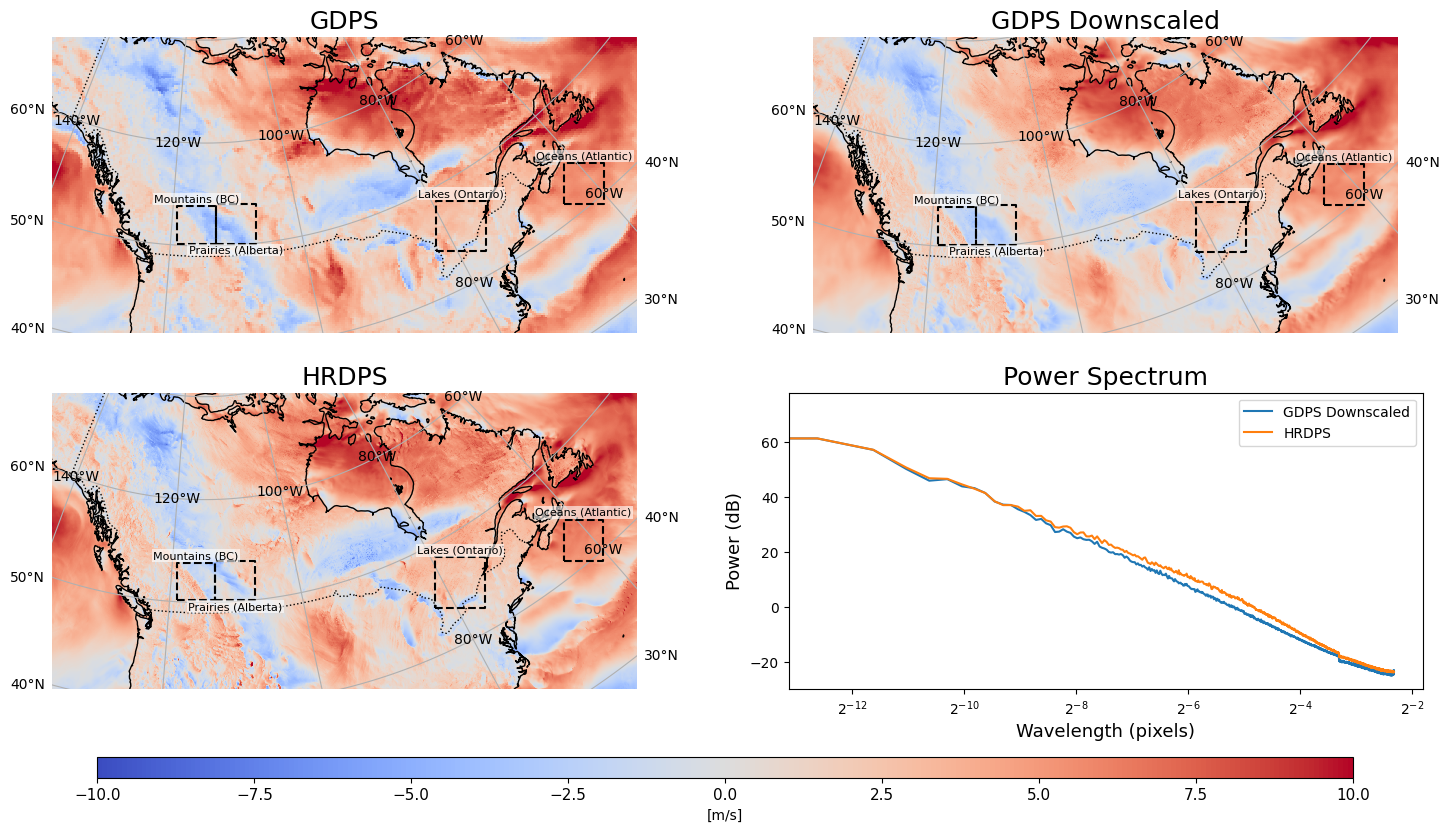

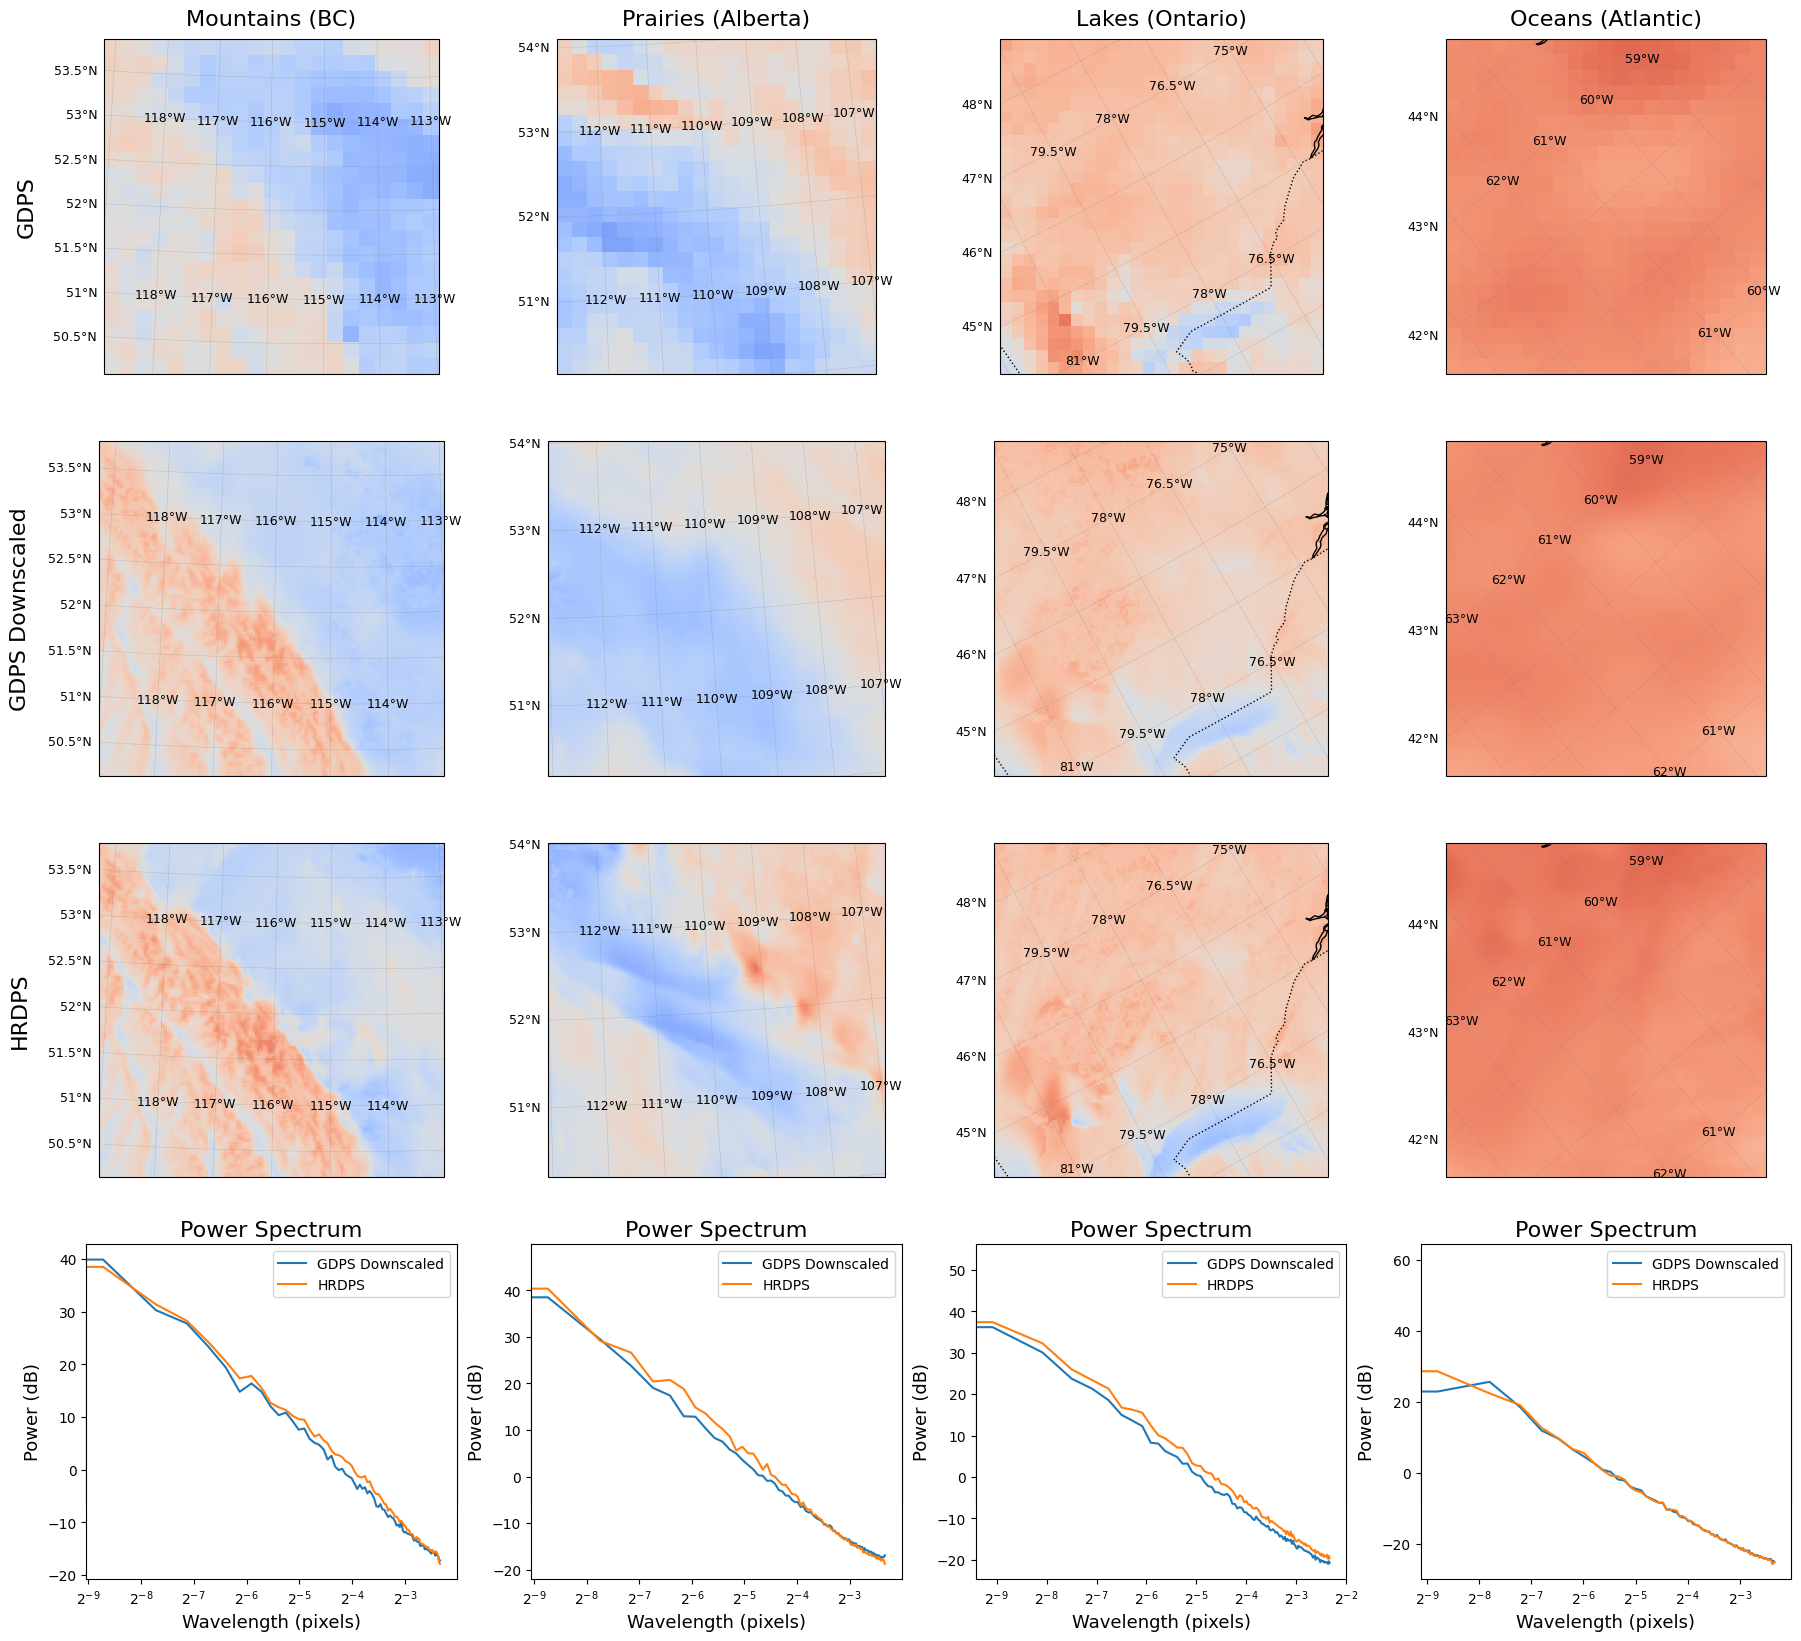

In [15]:
for idx in range(0, len(outputs)):
    var = output_vars.index(var_name)
    input_var = input_vars.index(var_name)
    var_name_tile = var_name 

    plot_input = inputs[idx, input_var, :, :].cpu().numpy()
    plot_target = targets[idx, var, : ,:].cpu().numpy()
    plot_pred = outputs[idx, var, :, :].cpu().numpy()
    plot_residual = plot_target - plot_pred

    plot_eccc_results(plot_input, plot_pred, plot_target)

In [16]:
from granitewxc.utils.eccc_contants import RLAT_GDPS, RLON_GDPS, RLAT_HRDPS, RLON_HRDPS 
from granitewxc.utils.eccc_contants import GRID_NORTH_POLE_LATITUDE, GRID_NORTH_POLE_LONGITUDE
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pysteps.utils.spectral import rapsd

regions = {
        "Mountains (BC)": (-116 - 5.88/2,
                            -116 + 5.88/2, 
                            52 - 3.6/2, 
                            52 + 3.6/2),  # Centered at (116ºW, 52ºN)
    }
rotated_crs = ccrs.RotatedPole(pole_latitude=GRID_NORTH_POLE_LATITUDE, pole_longitude=GRID_NORTH_POLE_LONGITUDE)


In [36]:

def plot_with_bbox(ax, data, rotated_crs, bounding_boxes, rlat, rlon, cmap='coolwarm', vmin=-10, vmax=10):
    mesh = ax.pcolormesh(rlon, rlat, data, cmap=cmap, transform=rotated_crs, vmin=vmin, vmax=vmax)
    
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.gridlines(draw_labels=True)
    
    rotated_crs = ccrs.RotatedPole(
        pole_latitude=GRID_NORTH_POLE_LATITUDE,
        pole_longitude=GRID_NORTH_POLE_LONGITUDE
    )
    
    geographic_crs = ccrs.PlateCarree()

    for name, (lon_min, lon_max, lat_min, lat_max) in bounding_boxes.items():
        lon_points = np.array([lon_min, lon_max, lon_max, lon_min])
        lat_points = np.array([lat_min, lat_min, lat_max, lat_max])

        rotated_points = rotated_crs.transform_points(geographic_crs, lon_points, lat_points)
        rotated_lon = rotated_points[:, 0]
        rotated_lat = rotated_points[:, 1]

        lon_min, lon_max = rotated_lon.min(), rotated_lon.max()
        lat_min, lat_max = rotated_lat.min(), rotated_lat.max()
        
        box_lon = [lon_min, lon_max, lon_max, lon_min, lon_min]
        box_lat = [lat_min, lat_min, lat_max, lat_max, lat_min]
        # make line thicker
        ax.plot(box_lon, box_lat, linestyle="--", color="black", label=name, linewidth=1)

        text_x = (lon_min + lon_max) / 2
        if name == 'Prairies (Alberta)':
            text_y = lat_min - 1.1  # offset below the box
        else:
            text_y = lat_max + 0.2  # offset above the box
        ax.text(
            text_x, text_y, name,
            transform=rotated_crs,
            horizontalalignment='center',
            verticalalignment='bottom',
            fontsize=14,
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1)
        )
    return mesh

/tmp/ipykernel_1444227/2480324905.py:92: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1300 with 1 Axes> than <Figure size 2000x500 with 5 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(


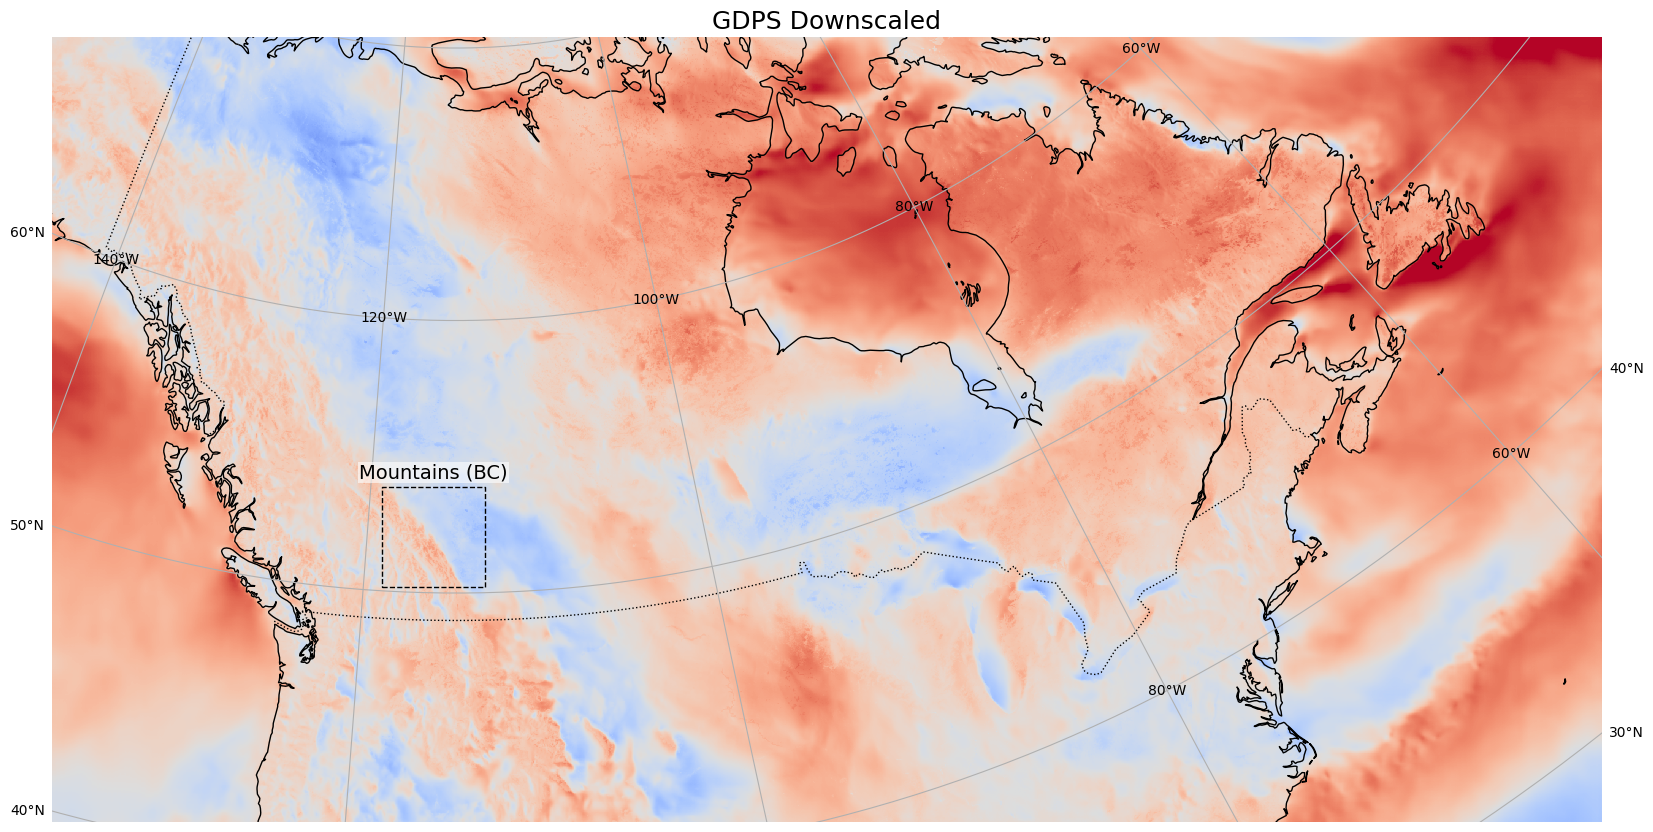

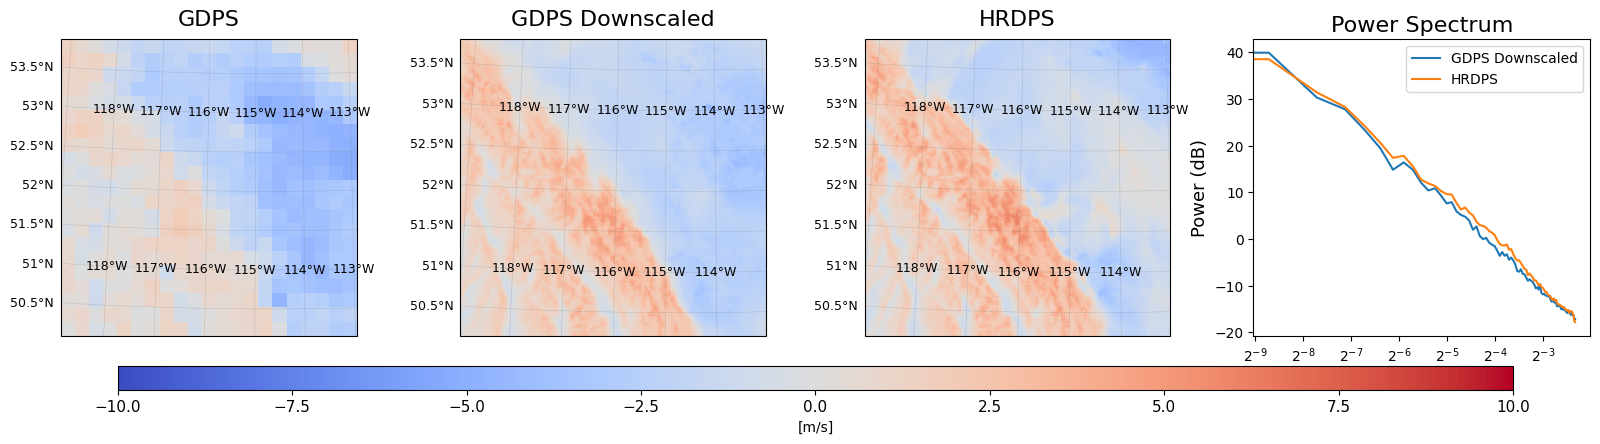

In [95]:

fig, ax = plt.subplots(1, 1, figsize=(20, 13), subplot_kw={'projection': rotated_crs})

im2 = plot_with_bbox(
    ax, plot_pred, rotated_crs, bounding_boxes=regions,
    rlat=RLAT_HRDPS, rlon=RLON_HRDPS,
)

ax.set_title("GDPS Downscaled", fontsize=18)
ax.axis('off')

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec
from granitewxc.utils.plot import convert_bbox_to_rotated, crop_region, plot_power_spectrum_with_rapsd

regions = {
    "Mountains (BC)": (-116 - 5.88/2,
                       -116 + 5.88/2, 
                       52 - 3.6/2, 
                       52 + 3.6/2),  # Centered at (116ºW, 52ºN)
}

rotated_crs = ccrs.RotatedPole(pole_latitude=GRID_NORTH_POLE_LATITUDE, pole_longitude=GRID_NORTH_POLE_LONGITUDE)

# Set up figure and grid layout
fig = plt.figure(figsize=(20, 5))
gs = GridSpec(1, 4, figure=fig)

# Create three map subplots with projection
axes = []
for i in range(3):
    ax = fig.add_subplot(gs[0, i], projection=rotated_crs)
    axes.append(ax)

# Create one non-map subplot for power spectrum
ax_psd = fig.add_subplot(gs[0, 3])
axes.append(ax_psd)  # axes[3] is now the power spectrum plot

datasets = [
    (plot_input, RLON_GDPS, RLAT_GDPS, "GDPS"),
    (plot_pred, RLON_HRDPS, RLAT_HRDPS, "GDPS Downscaled"),
    (plot_target, RLON_HRDPS, RLAT_HRDPS, "HRDPS")
]

for col, (region_name, (lon_min, lon_max, lat_min, lat_max)) in enumerate(regions.items()):
    rlon_min, rlon_max, rlat_min, rlat_max = convert_bbox_to_rotated(
        lon_min, lon_max, lat_min, lat_max, rotated_crs
    )

    cropped_maps = []

    for row, (data, rlon, rlat, title) in enumerate(datasets):
        ax = axes[row]

        try:
            cropped_data, cropped_rlon, cropped_rlat = crop_region(
                data, rlon, rlat, rlon_min, rlon_max, rlat_min, rlat_max
            )
            cropped_maps.append((cropped_data, title))

            pcm = ax.pcolormesh(cropped_rlon, cropped_rlat, cropped_data,
                                cmap='coolwarm', transform=rotated_crs, vmin=-10, vmax=10)

            ax.coastlines()
            ax.add_feature(cfeature.BORDERS, linestyle=':')

            gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.6, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {'size': 9}
            gl.ylabel_style = {'size': 9}

        except Exception as e:
            print(f"Skipping region '{region_name}' for dataset '{title}': {e}")
            ax.set_visible(False)
            continue

        if col == 0:
            ax.set_title(title, fontsize=16, pad=10)
        # if col == 0 and row == 0:
        #     ax.text(-0.2, 0.5, region_name, va='center', ha='right', rotation='vertical',
        #             fontsize=16, transform=ax.transAxes)

    # Power spectrum (axes[3])
    for data_cropped, label in cropped_maps:
        if label != 'GDPS':
            plot_power_spectrum_with_rapsd(data_cropped, ax_psd, label=label)
    ax_psd.set_title("Power Spectrum", fontsize=16)


cbar = fig.colorbar(
    im2,
    ax=axes,
    orientation='horizontal',
    pad=0.08,         
    aspect=60,        
    shrink=0.9,     
    location='bottom',
    label='[m/s]'
)
cbar.ax.tick_params(labelsize=11)

# plt.tight_layout()
plt.show()


In [41]:
n_regions

1

/tmp/ipykernel_1444227/1983708017.py:83: UserWarning: Adding colorbar to a different Figure <Figure size 1800x1100 with 2 Axes> than <Figure size 1600x400 with 5 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(


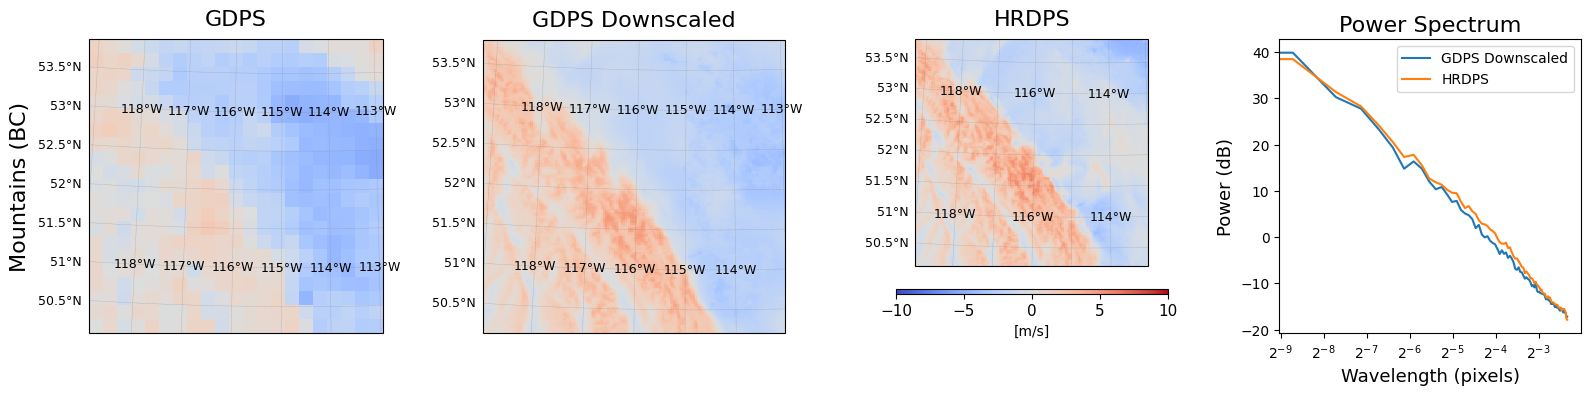